# Data Cleaning – AB_NYC_2019 Dataset

**Task:** Demonstrate data cleaning skills on the New York City Airbnb Open Data (2019).

**Dataset:** `AB_NYC_2019.csv` — Contains 48,895 Airbnb listings across NYC with 16 columns.

---
### Key Cleaning Steps Covered
| Step | Concept |
|------|--------|
| 1 | Data Loading & Initial Inspection |
| 2 | Missing Data Handling |
| 3 | Duplicate Removal |
| 4 | Standardization |
| 5 | Outlier Detection & Treatment |
| 6 | Data Integrity Verification |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for better output readability
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Load Dataset & Initial Inspection

In [2]:
# Load the raw dataset
df = pd.read_csv('AB_NYC_2019.csv')

print(f'Shape: {df.shape}')  # rows × columns
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# Column names, dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
# Basic statistics for numeric columns
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 3. Missing Data Handling

> **Observed:** `name` (16 nulls), `host_name` (21 nulls), `last_review` & `reviews_per_month` (10,052 nulls each — listings with zero reviews have no review date).

Missing values per column:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


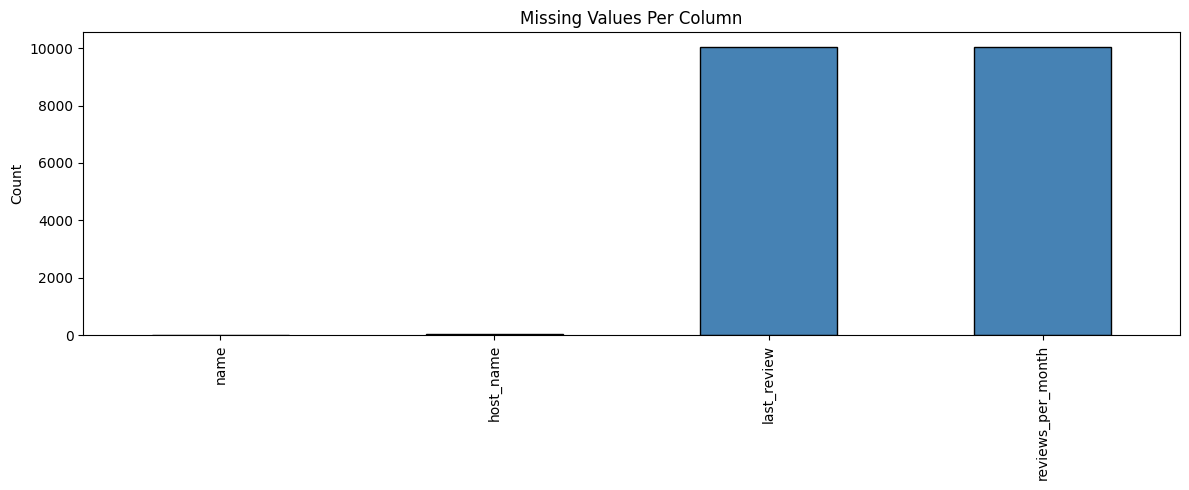

In [5]:
# Count and visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

print('Missing values per column:')
print(missing)

missing.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Missing Values Per Column')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Fill text fields with 'Unknown' (they are non-critical identifiers)
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

# reviews_per_month is NaN only when number_of_reviews == 0 → fill with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)

# Convert last_review to datetime; NaT stays for listings with no reviews
df['last_review'] = pd.to_datetime(df['last_review'])

print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


## 4. Duplicate Removal

In [7]:
print(f'Duplicate rows (full): {df.duplicated().sum()}')

# Drop any exact duplicate rows
df.drop_duplicates(inplace=True)

print(f'Shape after duplicate removal: {df.shape}')

Duplicate rows (full): 0
Shape after duplicate removal: (48895, 16)


## 5. Standardization

> Ensure consistent formatting — trim whitespace from categorical columns and cast ID fields to string (they are identifiers, not quantities).

In [8]:
# Strip leading/trailing whitespace from categorical columns
df['neighbourhood_group'] = df['neighbourhood_group'].str.strip()
df['neighbourhood'] = df['neighbourhood'].str.strip()
df['room_type'] = df['room_type'].str.strip()

# Convert IDs to string — they are labels, not numeric values
df['id'] = df['id'].astype(str)
df['host_id'] = df['host_id'].astype(str)

print('Unique neighbourhood groups:', df['neighbourhood_group'].unique())
print('Unique room types:', df['room_type'].unique())

Unique neighbourhood groups: ['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']
Unique room types: ['Private room' 'Entire home/apt' 'Shared room']


## 6. Outlier Detection & Treatment

### 6.1 Price Column

In [9]:
print(f'Listings with price = $0: {(df["price"] == 0).sum()}')
print(f'Max price: ${df["price"].max()}')

# Fix zero prices: replace with median price of the same room_type
room_medians = df.groupby('room_type')['price'].median()
print('\nMedian price per room type:')
print(room_medians)

Listings with price = $0: 11
Max price: $10000

Median price per room type:
room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64


In [10]:
# Replace $0 prices with the room-type median
def fix_zero_price(row):
    if row['price'] == 0:
        return room_medians[row['room_type']]
    return row['price']

df['price'] = df.apply(fix_zero_price, axis=1)

# Cap extreme high prices at 99th percentile to reduce right-skew
price_cap = df['price'].quantile(0.99)
print(f'99th percentile price cap: ${price_cap}')
df.loc[df['price'] > price_cap, 'price'] = price_cap

99th percentile price cap: $799.0


C:\Users\tpare\AppData\Local\Temp\ipykernel_24432\2677485042.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='price', palette='Set2')


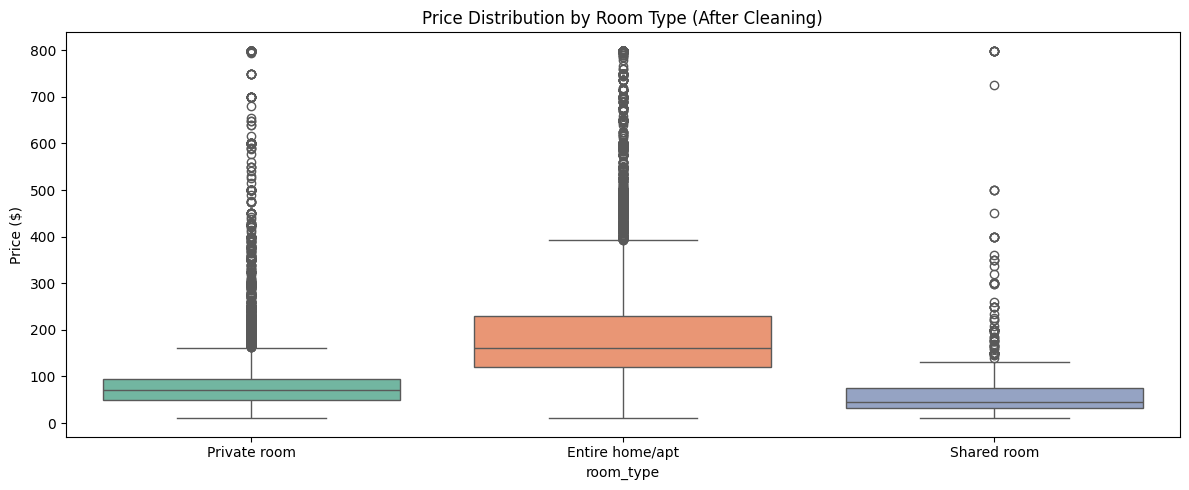

In [11]:
# Visualize price distribution before and after via boxplot per room type
sns.boxplot(data=df, x='room_type', y='price', palette='Set2')
plt.title('Price Distribution by Room Type (After Cleaning)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

### 6.2 Minimum Nights Column

In [12]:
print(f'Listings with minimum_nights > 365: {(df["minimum_nights"] > 365).sum()}')

# Cap minimum_nights at 365 — cannot require more than a full year
df.loc[df['minimum_nights'] > 365, 'minimum_nights'] = 365

print(f'Max minimum_nights after fix: {df["minimum_nights"].max()}')

Listings with minimum_nights > 365: 14
Max minimum_nights after fix: 365


In [13]:
# Plot outlier check using IQR method on price
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
outlier_count = ((df['price'] < Q1 - 1.5 * IQR) | (df['price'] > Q3 + 1.5 * IQR)).sum()

print(f'IQR range: ${Q1} – ${Q3}  |  IQR: {IQR}')
print(f'Remaining price outliers (IQR method): {outlier_count}')

IQR range: $69.0 – $175.0  |  IQR: 106.0
Remaining price outliers (IQR method): 2972


## 7. Data Integrity Verification

> Final checks to confirm the cleaned dataset is consistent and ready for analysis.

In [14]:
print('=== Final Data Quality Report ===')
print(f'Total rows     : {df.shape[0]}')
print(f'Total columns  : {df.shape[1]}')
print(f'Duplicates     : {df.duplicated().sum()}')
print(f'Null values    : {df.isnull().sum().sum()}')
print(f'Price range    : ${df["price"].min()} – ${df["price"].max()}')
print(f'Min nights max : {df["minimum_nights"].max()}')

=== Final Data Quality Report ===
Total rows     : 48895
Total columns  : 16
Duplicates     : 0
Null values    : 10052
Price range    : $10.0 – $799.0
Min nights max : 365


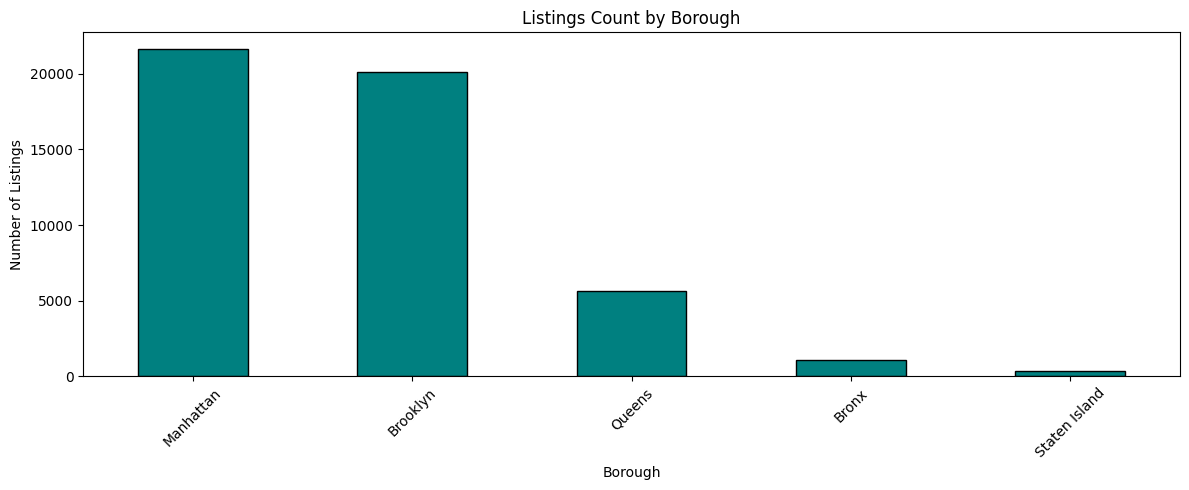

In [15]:
# Visualize listings count per neighbourhood group
df['neighbourhood_group'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Listings Count by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

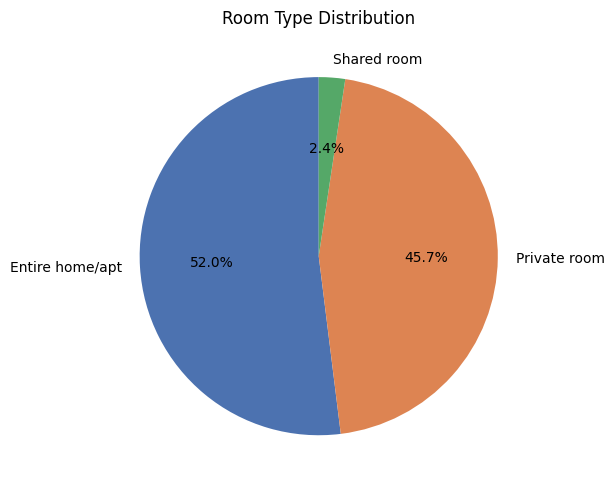

In [16]:
# Room type distribution
df['room_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#4C72B0','#DD8452','#55A868'])
plt.title('Room Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 8. Export Cleaned Dataset

In [17]:
# Save cleaned file for further analysis
df.to_csv('AB_NYC_2019_Cleaned.csv', index=False)

print('Cleaned dataset saved as AB_NYC_2019_Cleaned.csv')
df.head()

Cleaned dataset saved as AB_NYC_2019_Cleaned.csv


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,2018-11-19,0.10,1,0
